____
# PCF for Sim Data

In statistical mechanics, the radial distribution function, (or **pair correlation function**) g(r) in a system of particles (atoms, molecules, colloids, etc.), describes how density varies as a function of distance from a reference particle.



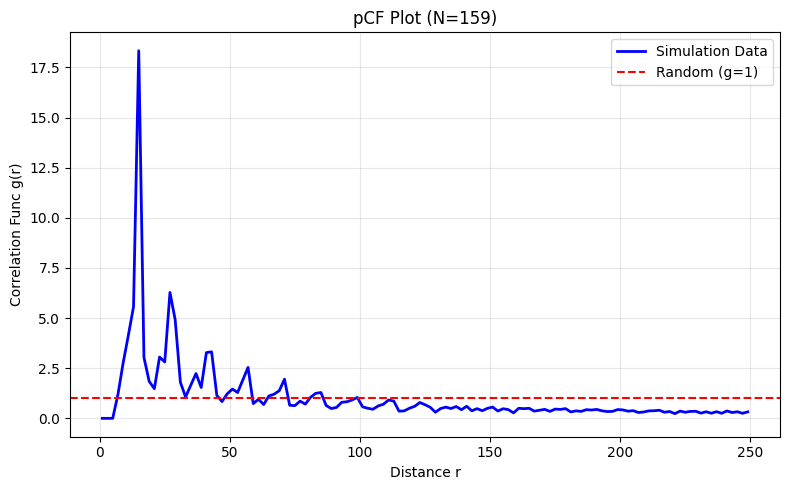

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.spatial.distance import pdist

def generate_pcf_plot(file_name, dr=2.0, r_max=250):
    """Computes the 2D pCF plot"""

    output = sio.loadmat(file_name)
    x_coords = output['cells'][1, :]
    y_coords = output['cells'][2, :]
    
    points = np.column_stack((x_coords, y_coords))
    N = len(points)
        
    # Compute pairwise distances
    distances = pdist(points)

    bins = np.arange(0, r_max + dr, dr)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    counts, _ = np.histogram(distances, bins=bins)

    # Normalize to estimate density
    width = np.max(x_coords) - np.min(x_coords)
    height = np.max(y_coords) - np.min(y_coords)
    area = width * height
    
    rho = N / area  # Number density
    
    # Expected pairs in each ring for a random distribution:
    ring_areas = np.pi * (bins[1:]**2 - bins[:-1]**2)
    expected_counts = (N * rho * ring_areas) / 2 # Need to divide by 2 since pdist counts only unique pairs

    g_r = counts / expected_counts

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(bin_centers, g_r, 'b-', linewidth=2, label='Simulation Data')
    plt.axhline(y=1.0, color='r', linestyle='--', label='Random (g=1)')
    
    plt.xlabel(f'Distance r')
    plt.ylabel(f'Correlation Func g(r)')
    plt.title(f'pCF Plot (N={N})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Run the function ---
generate_pcf_plot('output00000318_cells.mat')